# Análisis Exploratorio de Datos (AED): dataset *Titanic*

Dataset de pasajeros del Titanic incluido en Seaborn. Cada fila es un pasajero, con datos sobre su clase, sexo, edad, familia a bordo, tarifa, puerto de embarque y si sobrevivió al hundimiento (15 de abril de 1912).

La variable objetivo es **`survived`** (0 = no, 1 = sí). Todo el análisis gira en torno a una pregunta: **¿qué factores se asocian con sobrevivir?**

**Índice**
1. Carga de datos y estructura
2. Columnas redundantes
3. Perfil de las variables categóricas
4. Perfil de las variables numéricas
5. Calidad de los datos: nulos, duplicados y outliers
6. Limpieza e imputación
7. Variable objetivo: supervivencia
8. Supervivencia por sexo, clase y edad
9. Interacción sexo × clase
10. Familia a bordo
11. Puerto de embarque: un efecto de confusión
12. Tarifa
13. Correlaciones
14. Conclusiones y siguientes pasos

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 20)
pd.set_option("display.precision", 3)

## 1. Carga de datos y estructura

In [ ]:
df = sns.load_dataset("titanic")
print("Filas y columnas:", df.shape)
df.head()

Filas y columnas: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.250,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.283,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.925,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.100,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.050,S,Third,man,True,NaN,Southampton,no,True


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


Clasificamos las columnas:

| Tipo | Columnas |
|---|---|
| **Objetivo** | `survived` (y su copia `alive`) |
| **Categóricas** | `pclass`/`class`, `sex`, `embarked`/`embark_town`, `who`, `deck` |
| **Booleanas** | `adult_male`, `alone` |
| **Numéricas continuas** | `age`, `fare` |
| **Numéricas discretas** | `sibsp` (hermanos/cónyuges a bordo), `parch` (padres/hijos a bordo) |

**No hay identificador de pasajero** (ni nombre ni ID). Esto será importante al buscar duplicados.

## 2. Columnas redundantes

Varias columnas repiten la misma información con otro formato. Lo comprobamos:

In [ ]:
print("pclass ≡ class:      ",
      (df["pclass"].map({1: "First", 2: "Second", 3: "Third"}) == df["class"].astype(str)).all())
print("survived ≡ alive:    ",
      (df["survived"].map({0: "no", 1: "yes"}) == df["alive"]).all())
print("embarked ≡ embark_town:",
      (df["embarked"].map({"S": "Southampton", "C": "Cherbourg", "Q": "Queenstown"})
       == df["embark_town"]).sum(), "de", df["embarked"].notna().sum(), "coinciden")
print("alone ≡ (sibsp + parch == 0):",
      (df["alone"] == ((df["sibsp"] + df["parch"]) == 0)).all())
print("adult_male ≡ (who == 'man'):",
      (df["adult_male"] == (df["who"] == "man")).all())

pclass ≡ class:       True
survived ≡ alive:     True
embarked ≡ embark_town: 889 de 889 coinciden
alone ≡ (sibsp + parch == 0): True
adult_male ≡ (who == 'man'): True


Son **columnas derivadas**: `class`, `alive`, `embark_town`, `alone` y `adult_male` se calculan a partir de otras. Para el análisis nos quedamos con una versión de cada una.

⚠️ `alive` es exactamente la variable objetivo. Si se usara como predictor en un modelo, habría **fuga de información** (*data leakage*).

In [ ]:
df = df.drop(columns=["class", "alive", "embark_town"])
categoricas = ["sex", "pclass", "embarked", "who", "deck", "adult_male", "alone"]
numericas = ["age", "fare", "sibsp", "parch"]

## 3. Perfil de las variables categóricas

In [ ]:
for col in categoricas + ["survived"]:
    print(f"--- {col} ---")
    print(df[col].value_counts(dropna=False))
    print()

--- sex ---
sex
male      577
female    314
Name: count, dtype: int64

--- pclass ---
pclass
3    491
1    216
2    184
Name: count, dtype: int64

--- embarked ---
embarked
S      644
C      168
Q       77
NaN      2
Name: count, dtype: int64

--- who ---
who
man      537
woman    271
child     83
Name: count, dtype: int64

--- deck ---
deck
NaN    688
C       59
B       47
D       33
E       32
A       15
F       13
G        4
Name: count, dtype: int64

--- adult_male ---
adult_male
True     537
False    354
Name: count, dtype: int64

--- alone ---
alone
True     537
False    354
Name: count, dtype: int64

--- survived ---
survived
0    549
1    342
Name: count, dtype: int64



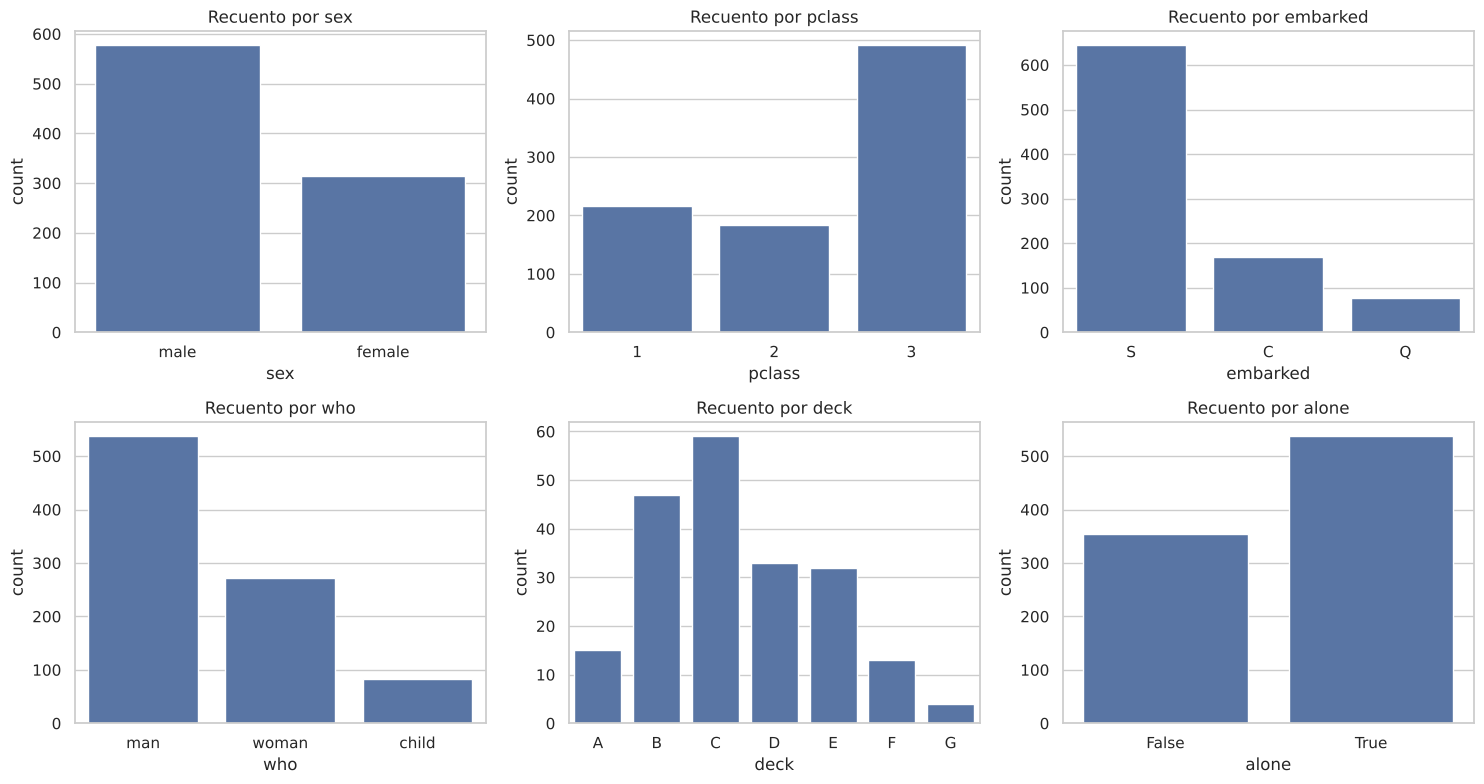

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, ["sex", "pclass", "embarked", "who", "deck", "alone"]):
    sns.countplot(data=df, x=col, ax=ax)
    ax.set_title(f"Recuento por {col}")
plt.tight_layout()
plt.show()

## 4. Perfil de las variables numéricas

In [ ]:
df[numericas].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).T

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
age,714.0,29.699,14.526,0.42,1.0,4.000,20.125,28.000,38.0,56.000,65.870,80.000
fare,891.0,32.204,49.693,0.00,0.0,7.225,7.910,14.454,31.0,112.079,249.006,512.329
sibsp,891.0,0.523,1.103,0.00,0.0,0.000,0.000,0.000,1.0,3.000,5.000,8.000
parch,891.0,0.382,0.806,0.00,0.0,0.000,0.000,0.000,0.0,2.000,4.000,6.000


In [ ]:
pd.DataFrame({
    "media": df[numericas].mean(),
    "mediana": df[numericas].median(),
    "asimetria": df[numericas].skew(),
    "ceros": (df[numericas] == 0).sum(),
})

,media,mediana,asimetria,ceros
age,29.699,28.000,0.389,0
fare,32.204,14.454,4.787,15
sibsp,0.523,0.000,3.695,608
parch,0.382,0.000,2.749,678


- `fare` tiene una **asimetría muy fuerte** (≈ 4,8): la mayoría pagó poco y unos pocos pagaron mucho (máximo 512). Su media (32) es más del doble que su mediana (14). En estos casos conviene usar la mediana o aplicar una transformación logarítmica.
- Hay **15 tarifas iguales a 0**. Pueden ser tripulación o invitados, o bien valores de relleno.

In [ ]:
df[df["fare"] == 0][["pclass", "sex", "age", "embarked", "survived"]]

,pclass,sex,age,embarked,survived
179,3,male,36.0,S,0
263,1,male,40.0,S,0
271,3,male,25.0,S,1
277,2,male,NaN,S,0
302,3,male,19.0,S,0
413,2,male,NaN,S,0
466,2,male,NaN,S,0
481,2,male,NaN,S,0
597,3,male,49.0,S,0
633,1,male,NaN,S,0


## 5. Calidad de los datos

### 5.1 Valores nulos

In [ ]:
nulos = pd.DataFrame({
    "nulos": df.isna().sum(),
    "porcentaje": (df.isna().mean() * 100).round(1),
})
nulos[nulos["nulos"] > 0].sort_values("porcentaje", ascending=False)

,nulos,porcentaje
deck,688,77.2
age,177,19.9
embarked,2,0.2


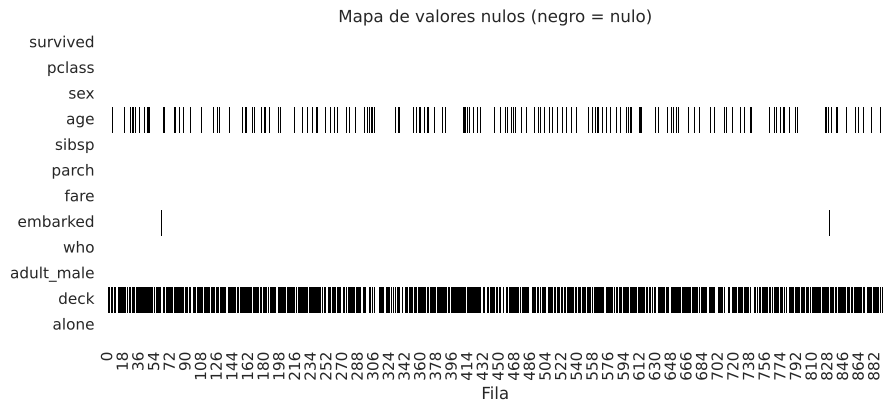

In [ ]:
plt.figure(figsize=(10, 4))
sns.heatmap(df.isna().T, cbar=False, cmap="Greys")
plt.title("Mapa de valores nulos (negro = nulo)")
plt.xlabel("Fila")
plt.show()

| Columna | % nulos | Valoración |
|---|---|---|
| `deck` | 77 % | Dispersa: casi inutilizable tal cual |
| `age` | 20 % | Incompleta: hay que imputar |
| `embarked` | 0,2 % | Solo 2 filas: se imputa con la moda |

¿Los nulos son **aleatorios**? Comprobamos si dependen de la clase:

In [ ]:
df.groupby("pclass")[["deck", "age"]].apply(lambda g: g.isna().mean()).round(2)

,deck,age
pclass,,
1,0.19,0.14
2,0.91,0.06
3,0.98,0.28


**No son aleatorios.** Falta la cubierta del 98 % de los pasajeros de 3ª clase, pero solo del 19 % de 1ª. El hecho de que falte `deck` ya informa de la clase social. Eliminar estas filas sesgaría el análisis.

### 5.2 Duplicados

In [ ]:
print("Filas duplicadas:", df.duplicated().sum())

Filas duplicadas: 107


Aparecen 107 filas "duplicadas", pero **no son errores**. Al no haber nombre ni ID, dos pasajeros distintos con el mismo perfil (mismo sexo, clase, tarifa y puerto, y sin edad registrada) resultan idénticos. **No se eliminan.**

In [ ]:
df[df.duplicated(keep=False)].sort_values(numericas).head(6)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,who,adult_male,deck,alone
469,1,3,female,0.75,2,1,19.258,C,child,False,NaN,False
644,1,3,female,0.75,2,1,19.258,C,child,False,NaN,False
163,0,3,male,17.00,0,0,8.662,S,man,True,NaN,True
500,0,3,male,17.00,0,0,8.662,S,man,True,NaN,True
844,0,3,male,17.00,0,0,8.662,S,man,True,NaN,True
144,0,2,male,18.00,0,0,11.500,S,man,True,NaN,True


### 5.3 Outliers (regla del 1,5 × IQR)

In [ ]:
def contar_outliers(serie):
    q1, q3 = serie.quantile([0.25, 0.75])
    iqr = q3 - q1
    return ((serie < q1 - 1.5 * iqr) | (serie > q3 + 1.5 * iqr)).sum()

df[numericas].apply(contar_outliers)

age       11
fare     116
sibsp     46
parch    213
dtype: int64

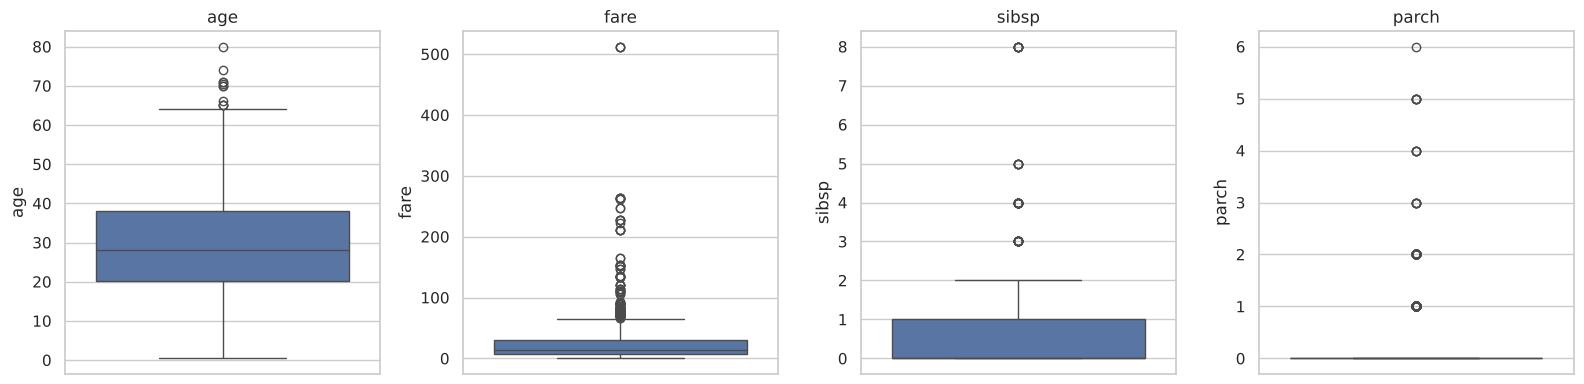

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, numericas):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

La regla del IQR marca 116 tarifas y 213 valores de `parch` como atípicos. Son valores **reales** (billetes de lujo, familias numerosas), no errores. La regla del IQR supone una distribución más o menos simétrica y aquí no funciona bien. **Un outlier estadístico no es necesariamente un error.**

## 6. Limpieza e imputación

In [ ]:
df_limpio = df.copy()

# embarked: 2 nulos -> moda
df_limpio["embarked"] = df_limpio["embarked"].fillna(df_limpio["embarked"].mode()[0])

# age: imputamos con la mediana de su grupo (sexo + clase), más fiel que la mediana global
mediana_grupo = df_limpio.groupby(["sex", "pclass"])["age"].transform("median")
df_limpio["age_imputada"] = df_limpio["age"].isna()
df_limpio["age"] = df_limpio["age"].fillna(mediana_grupo)

# deck: demasiados nulos -> lo convertimos en indicador "tiene cubierta registrada"
df_limpio["deck_conocida"] = df_limpio["deck"].notna()

print(df_limpio[["age", "embarked"]].isna().sum())

age         0
embarked    0
dtype: int64


In [ ]:
# Medianas de edad usadas para imputar
df.groupby(["sex", "pclass"])["age"].median().unstack()

pclass,1,2,3
sex,,,
female,35.0,28.0,21.5
male,40.0,30.0,25.0


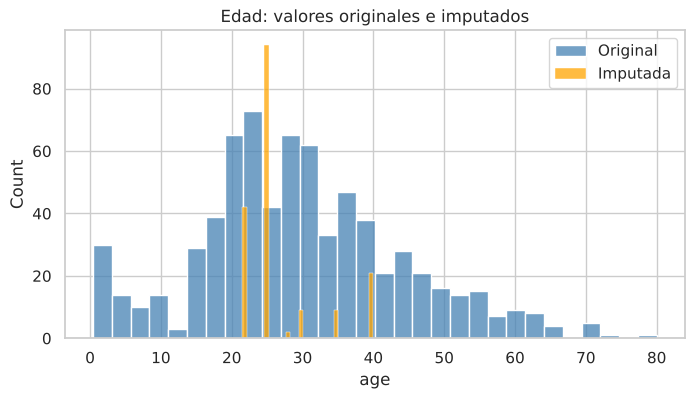

In [ ]:
# Efecto de la imputación sobre la distribución de la edad
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(df["age"].dropna(), bins=30, color="steelblue", label="Original", ax=ax)
sns.histplot(df_limpio.loc[df_limpio["age_imputada"], "age"], bins=30,
             color="orange", label="Imputada", ax=ax)
ax.legend()
ax.set_title("Edad: valores originales e imputados")
plt.show()

Los valores imputados se concentran en unas pocas edades (una por grupo) y crean picos artificiales. Es el precio de imputar con la mediana: **reduce la varianza**. Conviene tenerlo en cuenta al interpretar los resultados.

## 7. Variable objetivo: supervivencia

In [ ]:
tasa = df_limpio["survived"].mean()
print(f"Tasa global de supervivencia: {tasa:.1%}")
df_limpio["survived"].value_counts()

Tasa global de supervivencia: 38.4%


survived
0    549
1    342
Name: count, dtype: int64

Solo sobrevivió el 38 % de los pasajeros. Las clases están **desbalanceadas** (62/38), aunque no de forma extrema.

## 8. Supervivencia por sexo, clase y edad

In [ ]:
for col in ["sex", "pclass", "who"]:
    print(df_limpio.groupby(col)["survived"].agg(tasa="mean", n="count").round(3))
    print()

         tasa    n
sex               
female  0.742  314
male    0.189  577

         tasa    n
pclass            
1       0.630  216
2       0.473  184
3       0.242  491

        tasa    n
who              
child  0.590   83
man    0.164  537
woman  0.756  271



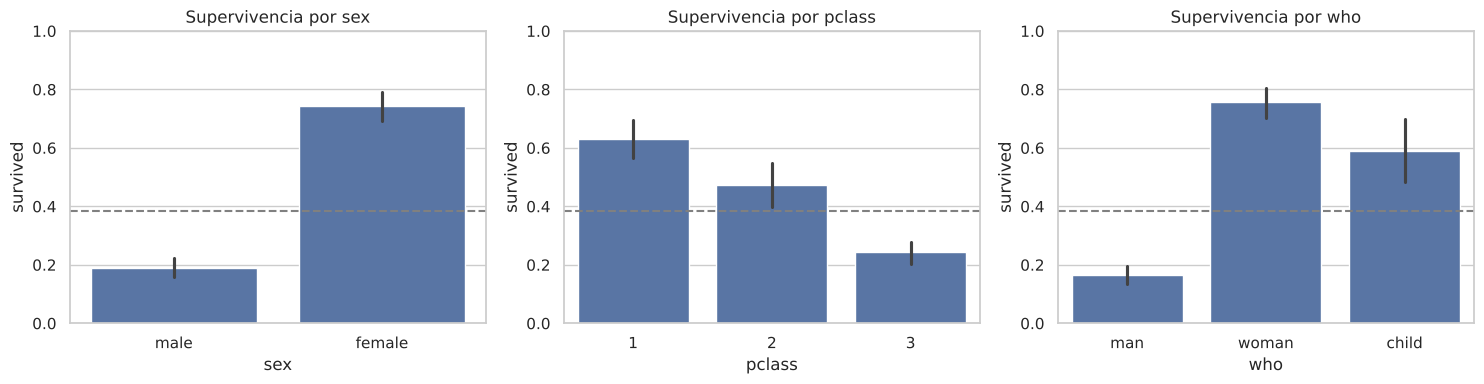

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["sex", "pclass", "who"]):
    sns.barplot(data=df_limpio, x=col, y="survived", ax=ax)
    ax.axhline(tasa, ls="--", color="grey")
    ax.set_title(f"Supervivencia por {col}")
    ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

**Prueba χ² de independencia**: ¿la supervivencia es independiente del sexo o de la clase?
- H₀: son independientes.
- Si p < 0,05, rechazamos H₀.

In [ ]:
for col in ["sex", "pclass"]:
    tabla = pd.crosstab(df_limpio[col], df_limpio["survived"])
    chi2, p, gl, _ = stats.chi2_contingency(tabla)
    print(f"{col:7s} χ² = {chi2:6.1f}  gl = {gl}  p = {p:.2e}")

sex     χ² =  260.7  gl = 1  p = 1.20e-58
pclass  χ² =  102.9  gl = 2  p = 4.55e-23


### Edad

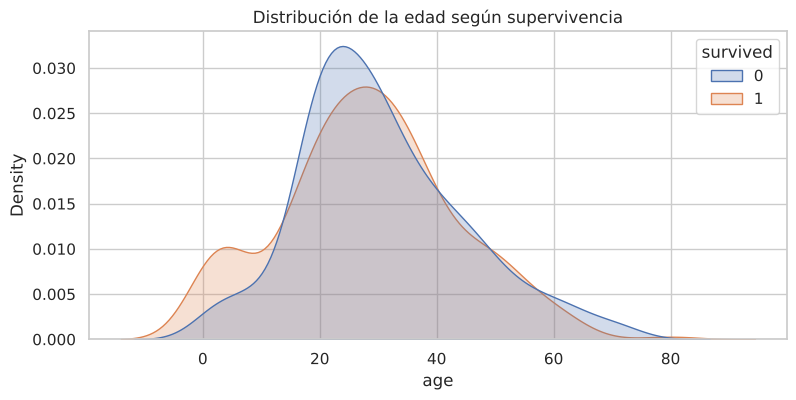

In [ ]:
# Usamos la edad ORIGINAL (sin imputar) para no distorsionar la comparación
fig, ax = plt.subplots(figsize=(9, 4))
sns.kdeplot(data=df, x="age", hue="survived", common_norm=False, fill=True, ax=ax)
ax.set_title("Distribución de la edad según supervivencia")
plt.show()

In [ ]:
df["grupo_edad"] = pd.cut(df["age"], bins=[0, 12, 18, 30, 50, 80],
                          labels=["0-12", "13-18", "19-30", "31-50", "51-80"])
df.groupby("grupo_edad", observed=True)["survived"].agg(tasa="mean", n="count").round(3)

,tasa,n
grupo_edad,,
0-12,0.580,69
13-18,0.429,70
19-30,0.356,270
31-50,0.423,241
51-80,0.344,64


Los niños de 12 años o menos sobrevivieron mucho más (58 %). A partir de esa edad la relación es débil. La edad importa sobre todo como **niño / adulto**, que es justo lo que recoge la columna `who`.

## 9. Interacción sexo × clase

In [ ]:
pd.crosstab(df_limpio["pclass"], df_limpio["sex"],
            values=df_limpio["survived"], aggfunc="mean").round(3)

sex,female,male
pclass,,
1,0.968,0.369
2,0.921,0.157
3,0.500,0.135


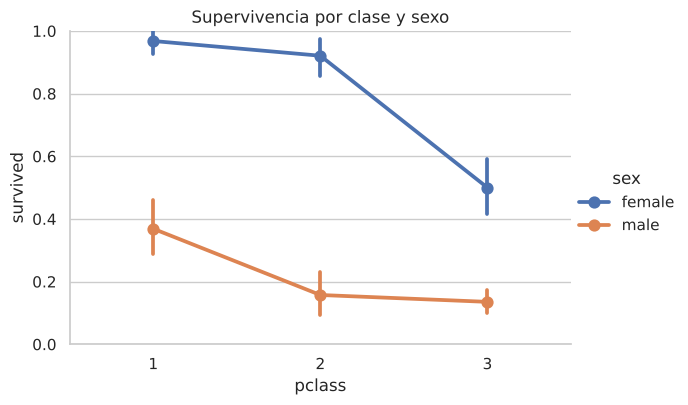

In [ ]:
sns.catplot(data=df_limpio, x="pclass", y="survived", hue="sex", kind="point", height=4, aspect=1.5)
plt.title("Supervivencia por clase y sexo")
plt.ylim(0, 1)
plt.show()

El efecto de la clase **depende del sexo**:
- Mujeres: ~95 % en 1ª y 2ª clase, pero solo 50 % en 3ª.
- Hombres: 37 % en 1ª, y entre 14 y 16 % en 2ª y 3ª.

Es una **interacción**. Mirar cada variable por separado no la detecta.

## 10. Familia a bordo

In [ ]:
df_limpio["tam_familia"] = df_limpio["sibsp"] + df_limpio["parch"] + 1
df_limpio.groupby("tam_familia")["survived"].agg(tasa="mean", n="count").round(2)

,tasa,n
tam_familia,,
1,0.30,537
2,0.55,161
3,0.58,102
4,0.72,29
5,0.20,15
6,0.14,22
7,0.33,12
8,0.00,6
11,0.00,7


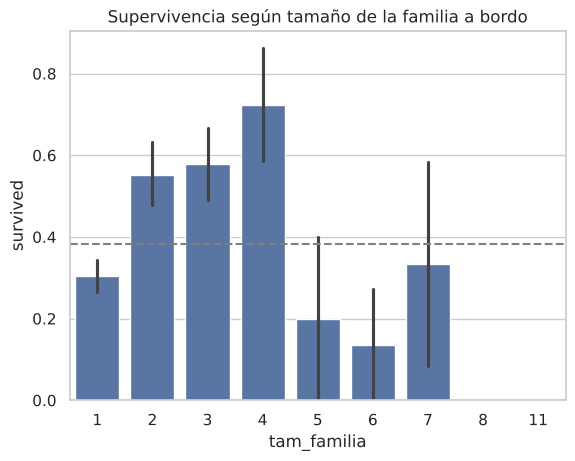

In [ ]:
sns.barplot(data=df_limpio, x="tam_familia", y="survived")
plt.axhline(tasa, ls="--", color="grey")
plt.title("Supervivencia según tamaño de la familia a bordo")
plt.show()

La relación **no es lineal**: viajar solo (30 %) o en familias de 5 o más (≤ 20 %) es peor que en familias de 2 a 4 (55-72 %). Por eso la correlación lineal de `sibsp` y `parch` con `survived` sale casi nula aunque la variable sí importe. Crear `tam_familia` es un ejemplo de **ingeniería de características**.

## 11. Puerto de embarque: un efecto de confusión

In [ ]:
df_limpio.groupby("embarked")["survived"].agg(tasa="mean", n="count").round(3)

,tasa,n
embarked,,
C,0.554,168
Q,0.390,77
S,0.339,646


Los embarcados en Cherbourg (C) sobrevivieron más. ¿Fue por el puerto? Miremos qué clase de pasajeros subió en cada uno:

In [ ]:
pd.crosstab(df_limpio["embarked"], df_limpio["pclass"], normalize="index").round(2)

pclass,1,2,3
embarked,,,
C,0.51,0.10,0.39
Q,0.03,0.04,0.94
S,0.20,0.25,0.55


In [ ]:
# Supervivencia por puerto DENTRO de cada clase
pd.crosstab(df_limpio["embarked"], df_limpio["pclass"],
            values=df_limpio["survived"], aggfunc="mean").round(2)

pclass,1,2,3
embarked,,,
C,0.69,0.53,0.38
Q,0.50,0.67,0.38
S,0.59,0.46,0.19


La mitad de los pasajeros de Cherbourg viajaba en 1ª clase, mientras que en Queenstown (Q) el 94 % iba en 3ª. Gran parte de la ventaja de Cherbourg se debe a la **clase**, que actúa como *variable de confusión* (*confounder*).

Aun así, dentro de 3ª clase Southampton sigue muy por debajo (19 % frente a 38 %). ¿Hay otra variable de confusión? Miremos el sexo:

In [ ]:
tercera = df_limpio[df_limpio["pclass"] == 3]
print("Proporción de mujeres en 3ª clase por puerto:")
print(tercera.groupby("embarked")["sex"].apply(lambda s: (s == "female").mean()).round(2))
print()
print("Supervivencia en 3ª clase por puerto y sexo:")
pd.crosstab(tercera["embarked"], tercera["sex"], values=tercera["survived"], aggfunc="mean").round(2)

Proporción de mujeres en 3ª clase por puerto:
embarked
C    0.35
Q    0.46
S    0.25
Name: sex, dtype: float64

Supervivencia en 3ª clase por puerto y sexo:


sex,female,male
embarked,,
C,0.65,0.23
Q,0.73,0.08
S,0.38,0.13


- En 3ª clase, Southampton tenía menos mujeres (25 %, frente a 35-46 %). Eso explica otra parte de la diferencia.
- Pero **incluso entre las mujeres de 3ª clase**, las de Southampton sobrevivieron menos (38 % frente a 65-73 %). Con estos datos no podemos explicar esa diferencia: puede deberse a otros factores (familias más numerosas, ubicación de los camarotes…), y los grupos de C y Q son pequeños.

**Lección**: una diferencia entre grupos puede deberse total o parcialmente a otras variables. Hay que controlarlas antes de atribuir el efecto a la variable que estamos mirando.

## 12. Tarifa

In [ ]:
df_limpio.groupby("pclass")["fare"].agg(["median", "mean", "max"]).round(1)

,median,mean,max
pclass,,,
1,60.3,84.2,512.3
2,14.2,20.7,73.5
3,8.0,13.7,69.6


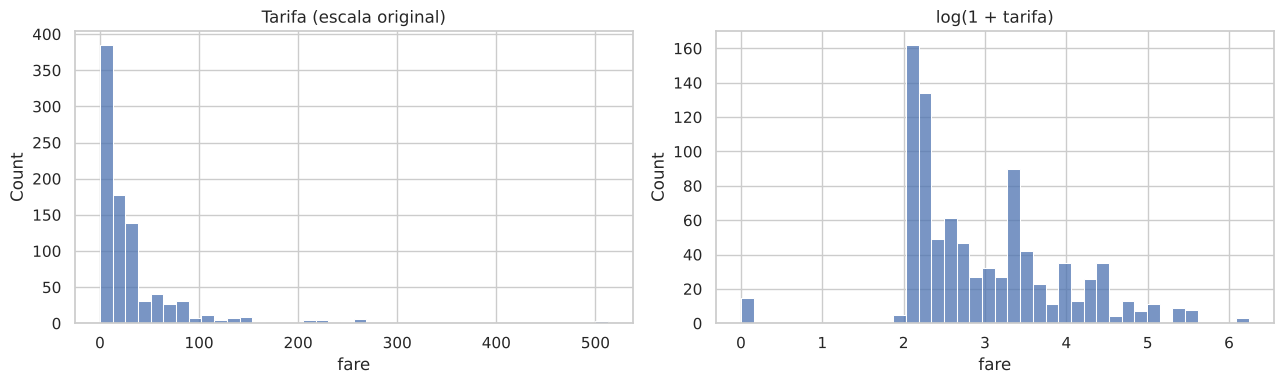

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(df_limpio["fare"], bins=40, ax=axes[0])
axes[0].set_title("Tarifa (escala original)")
sns.histplot(np.log1p(df_limpio["fare"]), bins=40, ax=axes[1])
axes[1].set_title("log(1 + tarifa)")
plt.tight_layout()
plt.show()

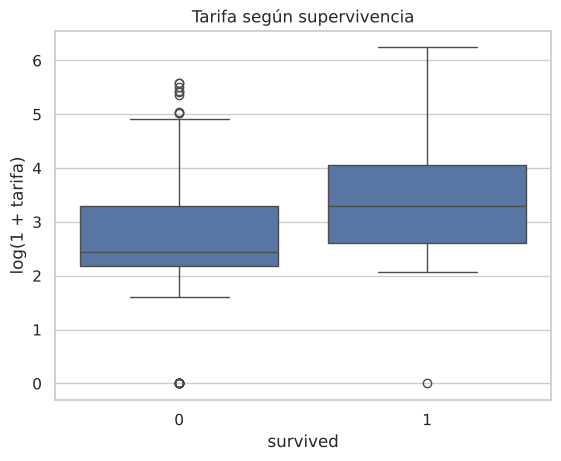

Mann-Whitney U = 129952, p = 4.55e-22


In [ ]:
sns.boxplot(data=df_limpio, x="survived", y=np.log1p(df_limpio["fare"]))
plt.ylabel("log(1 + tarifa)")
plt.title("Tarifa según supervivencia")
plt.show()

# Prueba no paramétrica de Mann-Whitney (la tarifa no es normal)
u, p = stats.mannwhitneyu(df_limpio.loc[df_limpio["survived"] == 1, "fare"],
                          df_limpio.loc[df_limpio["survived"] == 0, "fare"])
print(f"Mann-Whitney U = {u:.0f}, p = {p:.2e}")

La transformación logarítmica corrige la asimetría. Los supervivientes pagaron tarifas significativamente más altas, en buena parte porque la tarifa refleja la clase.

## 13. Correlaciones

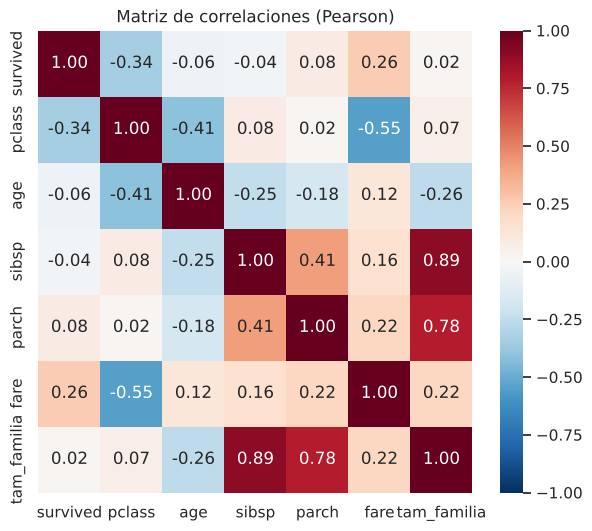

In [ ]:
cols_corr = ["survived", "pclass", "age", "sibsp", "parch", "fare", "tam_familia"]
corr = df_limpio[cols_corr].corr()

plt.figure(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1)
plt.title("Matriz de correlaciones (Pearson)")
plt.show()

In [ ]:
# Correlación de cada variable con la supervivencia, ordenada por magnitud
corr["survived"].drop("survived").sort_values(key=abs, ascending=False)

pclass        -0.338
fare           0.257
parch          0.082
age           -0.060
sibsp         -0.035
tam_familia    0.017
Name: survived, dtype: float64

- `pclass` (−0,34) y `fare` (+0,26) son las variables numéricas más asociadas a la supervivencia. Además están correlacionadas entre sí (−0,55).
- `sex` no aparece porque es texto. Su asociación es la más fuerte de todas, como mostró el χ².
- `tam_familia` sale cerca de 0 aunque sí influye: **Pearson solo mide relaciones lineales**.

In [ ]:
# Convertimos sex a número para incluirlo
df_limpio["es_mujer"] = (df_limpio["sex"] == "female").astype(int)
print(f"Correlación es_mujer - survived: {df_limpio['es_mujer'].corr(df_limpio['survived']):.2f}")

Correlación es_mujer - survived: 0.54


## 14. Conclusiones y siguientes pasos

**Calidad de los datos**
1. Hay 3 columnas redundantes (`class`, `alive`, `embark_town`). `alive` provocaría fuga de información.
2. Nulos **no aleatorios**: `deck` (77 %) y `age` (20 %) faltan sobre todo en 3ª clase.
3. Los 107 "duplicados" son pasajeros distintos con el mismo perfil; no hay un ID que los distinga.
4. Los outliers de `fare` y `parch` son valores reales, no errores.

**Factores de supervivencia**
1. **Sexo**: es el factor más fuerte (74 % de las mujeres frente al 19 % de los hombres). Refleja la norma de *"mujeres y niños primero"*.
2. **Clase**: 63 % en 1ª, 47 % en 2ª y 24 % en 3ª.
3. **Interacción sexo × clase**: las mujeres de 3ª clase perdieron gran parte de la ventaja de su sexo.
4. **Edad**: los niños de 12 años o menos sobrevivieron más; para el resto el efecto es débil.
5. **Familia**: relación no lineal, con el mejor resultado en familias de 2 a 4 personas.
6. **Puerto**: su efecto aparente se explica en gran parte por la clase y el sexo (confusión). Queda una diferencia residual en 3ª clase que estos datos no explican.

**Siguientes pasos propuestos**
- Modelo de clasificación (regresión logística o árbol de decisión) con `sex`, `pclass`, `age`, `tam_familia` y `fare`.
- Extraer el título (Mr, Mrs, Miss, Master…) del dataset original de Kaggle, que incluye el nombre, para imputar la edad mejor.
- Comparar distintos métodos de imputación de la edad (mediana por grupo, KNN, modelo) y su efecto en el modelo.